## Modelo de Regresión Logística

En esta sección se ajusta un modelo de regresión logística utilizando las variables e interacciones seleccionadas en la etapa anterior mediante el método LASSO.

La regresión logística resulta adecuada debido a que la variable respuesta es dicotómica (`swing`), permitiendo modelar la probabilidad de ocurrencia del evento en función de las características del lanzamiento y del contexto del turno al bate. 

In [34]:
# Cargamos los paquetes necesarios 
import polars as pl
import pyprojroot
import statsmodels.formula.api as smf
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt


In [35]:
# Definir la ruta raiz del proyecto
ROOT = pyprojroot.here()

# Cargamos los datos
datos_entrenamiento = pl.read_parquet(ROOT / "datos" / "train.parquet")
datos_validacion = pl.read_parquet(ROOT / "datos" / "test.parquet")

Una vez cargados los datos, se ajusta el modelo de regresión logística utilizando el paquete `statsmodels`.

In [22]:
datos_entrenamiento_pd = datos_entrenamiento.to_pandas()

modelo_regresion_logistica = smf.logit(
    formula="""
    swing ~ altura_zona
    + plate_x
    + plate_z
    + pitch_type
    + release_speed
    + balls
    + strikes
    + altura_zona:pitch_type
    + plate_z:pitch_type
    + release_speed:pitch_type
    + plate_x:pitch_type
    + plate_x:plate_z
    """,
    data=datos_entrenamiento_pd
).fit(maxiter=200)

modelo_regresion_logistica.summary()

         Current function value: 0.604784
         Iterations: 200


C:\Users\vicky\TP2_python\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  swing   No. Observations:               567881
Model:                          Logit   Df Residuals:                   567802
Method:                           MLE   Df Model:                           78
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.1258
Time:                        18:11:45   Log-Likelihood:            -3.4345e+05
converged:                      False   LL-Null:                   -3.9289e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                        -13.0064      0.278    -46.838      0.000     -13.551     -12.462
pitch_type[T.CS]                  -6.1949      5.724     -1.082      0.279     -17.414       5.024
pitch_type[T.CU]                  -3.1582      0.420     -7.521      0.000      -3.981      -2.335
pitch_type[T.EP]                  20.0059      5.217      3.835      0.000       9.782      30.230
pitch_type[T.FA]                  20.7986      1.674     12.426      0.000      17.518      24.079
pitch_type[T.FC]                  -1.3436      0.459     -2.925      0.003      -2.244      -0.443
pitch_type[T.FF]                  -1.1807      0.346     -3.410      0.001      -1.859      -0.502
pitch_type[T.FS]                  -2.1470      0.892     -2.408      0.016      -3.894      -0.400
pitch_type[T.KC]                  -6.1853      0.733     -8.440      0.000      -7.622      -4.749
pitch_type[T.KN]                   4.1749      7.640      0.546      0.585     -10.799      19.148
pitch_type[T.PO]                   2.5735     45.091      0.057      0.954     -85.802      90.949
pitch_type[T.SC]                   0.0034   1.49e+13   2.31e-16      1.000   -2.91e+13    2.91e+13
pitch_type[T.SI]                   0.8550      0.387      2.206      0.027       0.096       1.614
pitch_type[T.SL]                  -3.8203      0.360    -10.614      0.000      -4.526      -3.115
pitch_type[T.ST]                  -2.6602      0.936     -2.841      0.004      -4.495      -0.825
pitch_type[T.SV]                  -7.0336      2.254     -3.121      0.002     -11.451      -2.616
altura_zona                        6.6351      0.095     70.099      0.000       6.450       6.821
altura_zona:pitch_type[T.CS]       1.6998      2.529      0.672      0.501      -3.256       6.656
altura_zona:pitch_type[T.CU]       0.9067      0.152      5.972      0.000       0.609       1.204
altura_zona:pitch_type[T.EP]     -11.2185      2.329     -4.816      0.000     -15.784      -6.653
altura_zona:pitch_type[T.FA]     -10.3731      0.813    -12.766      0.000     -11.966      -8.781
altura_zona:pitch_type[T.FC]       0.3385      0.155      2.184      0.029       0.035       0.642
altura_zona:pitch_type[T.FF]      -0.5377      0.108     -4.996      0.000      -0.749      -0.327
altura_zona:pitch_type[T.FS]       0.8770      0.281      3.124      0.002       0.327       1.427
altura_zona:pitch_type[T.KC]       1.1971      0.247      4.846      0.000       0.713       1.681
altura_zona:pitch_type[T.KN]      -1.3718      3.399     -0.404      0.686      -8.033       5.289
altura_zona:pitch_type[T.PO]       1.7962     20.756      0.087      0.931     -38.885      42.477
altura_zona:pitch_type[T.SC]       0.0064        nan        nan        nan         nan         nan
altura_zona:pitch_type[T.SI]      -0.6160      0.122     -5.035      0.000      -0.856      -0.376
altura_zona:pitch_type[T.SL]       0.5946      0.122      4.870      0.00

A partir del modelo ajustado, se obtienen las probabilidades predichas utilizando la partición de `temporada1.parquet` destinada a validar el modelo.

In [23]:
datos_validacion_pd = datos_validacion.to_pandas()

In [28]:
probabilidades_validacion = modelo_regresion_logistica.predict(
    datos_validacion_pd
)

### Desempeño del modelo

A continuación se calculan algunas métricas que sirven para analizar la capacidad predictiva del modelo. 

In [ ]:

logloss_mrl = log_loss(
    datos_validacion_pd["swing"],
    probabilidades_validacion
)

print("Log-loss:", logloss_mrl)

Log-loss: 0.6050364843932806


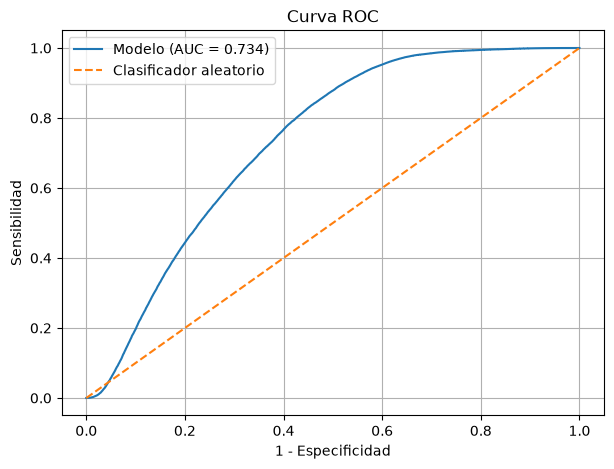

In [ ]:

# Cálculo de puntos de la curva ROC
fpr, tpr, umbrales = roc_curve(
    datos_validacion_pd["swing"],
    probabilidades_validacion
)

# Cálculo del AUC
auc = roc_auc_score(
    datos_validacion_pd["swing"],
    probabilidades_validacion
)

# Gráfico ROC
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Modelo (AUC = {auc:.3f})"
)

# Línea del clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)

plt.show()

Para evaluar el desempeño del modelo de regresión logística se analizaron el log-loss y la curva ROC. El valor obtenido de log-loss fue de 0.605, indicando que las probabilidades estimadas por el modelo presentan un ajuste razonable respecto de las clases observadas. 

Por otro lado, la curva ROC permitió evaluar la capacidad del modelo para discriminar entre lanzamientos con swing y sin swing para distintos valores de umbral. La curva se ubicó por encima de la diagonal correspondiente a un clasificador aleatorio, evidenciando que el modelo posee capacidad predictiva. El área bajo la curva obtenida fue AUC = 0.734, lo que indica una capacidad discriminativa moderada: el modelo logra ordenar correctamente la probabilidad de swing frente a no swing en aproximadamente un 73% de los casos seleccionados aleatoriamente.


Para complementar la evaluación del modelo mediante el log-loss y la curva ROC, se calcularon diferentes métricas de desempeño a partir de las predicciones obtenidas. Para ello, las probabilidades estimadas por el modelo fueron transformadas en decisiones binarias utilizando un punto de corte de 0.5, permitiendo comparar los lanzamientos predichos como swing o no swing con los resultados observados.

La sensibilidad permite evaluar la capacidad del modelo para identificar correctamente aquellos lanzamientos en los que el bateador realizó swing, mientras que la especificidad mide la proporción de lanzamientos sin swing correctamente reconocidos. Además, se calcularon el valor predictivo positivo (VPP) y el valor predictivo negativo (VPN), que permiten analizar la confiabilidad de las predicciones realizadas por el modelo. Finalmente, se incluyó el F1-score como una medida conjunta del desempeño, ya que resume el equilibrio entre la sensibilidad y el VPP. Los resultados obtenidos se presentan en la siguiente tabla.



In [ ]:

# Clasificación usando umbral 0.5
predicciones = (probabilidades_validacion >= 0.5).astype(int)

# Matriz de confusión
tn, fp, fn, tp = confusion_matrix(
    datos_validacion_pd["swing"],
    predicciones
).ravel()

# Métricas
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

tabla_metricas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Sensibilidad",
        "Especificidad",
        "VPP",
        "VPN",
        "F1-SCORE"
    ],
    "Valor": [
        accuracy_score(datos_validacion_pd["swing"], predicciones),
        sensibilidad,
        especificidad,
        vpp,
        vpn,
        f1_score(datos_validacion_pd["swing"], predicciones)
    ]
})

tabla_metricas

,Métrica,Valor
0,Accuracy,0.665467
1,Sensibilidad,0.639860
2,Especificidad,0.688592
3,VPP,0.649814
4,VPN,0.679197
5,F1-SCORE,0.644798


Al analizar las métricas obtenidas utilizando un punto de corte de 0.5, se observa que el modelo alcanza una proporción de aciertos global del 66,5%. La sensibilidad indica que el modelo logra identificar correctamente el 64% de los lanzamientos en los que el bateador realiza swing, mientras que la especificidad alcanza un valor de 68,9%, mostrando una mayor capacidad para reconocer los lanzamientos sin swing.

Los valores predictivos muestran un comportamiento similar: las predicciones de no swing presentan un valor superior (VPN = 0,679) respecto de las predicciones de swing (VPP = 0,650). Finalmente, el F1-score obtenido (0,645) evidencia un equilibrio moderado entre la detección de swings y la proporción de predicciones positivas correctas. En conjunto, las métricas indican que el modelo presenta un desempeño aceptable, aunque todavía existe una proporción considerable de lanzamientos que son clasificados incorrectamente.
